In [2]:
from langgraph.graph import Graph

In [3]:
def function3(input3):
    return input3 + "from third function"

In [4]:
def function1(input1):
    return input1 + "from first function"

def function2(input2):
    output = function3(" this is function2 in between")
    return input2 + "from second function" + output


In [5]:
workflow1 = Graph()


In [6]:
workflow1.add_node("function1", function1)
workflow1.add_node("function2", function2)

In [7]:
workflow1.add_edge("function1","function2")

In [8]:
workflow1.set_entry_point("function1")

In [9]:
workflow1.set_finish_point("function2")

In [10]:
app1 = workflow1.compile()

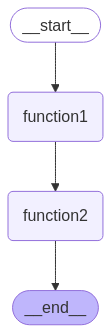

In [11]:
from IPython.display import Image,display 

display(Image(app1.get_graph().draw_mermaid_png()))

In [12]:
app1.invoke("Hi,I am Dhanush")

'Hi,I am Dhanushfrom first functionfrom second function this is function2 in betweenfrom third function'

In [13]:
input = "hi , I am Dhanushkumar"

In [14]:
for output in app1.stream(input):
    for k,v in output.items():
        print(k,v)

function1 hi , I am Dhanushkumarfrom first function
function2 hi , I am Dhanushkumarfrom first functionfrom second function this is function2 in betweenfrom third function


In [15]:
#create a workflow with llm 

from langchain_google_genai import GoogleGenerativeAI,GoogleGenerativeAIEmbeddings,ChatGoogleGenerativeAI
import os

In [ ]:
GOOGLE_API_KEY = ""

In [17]:
os.environ['GOOGLE_API_KEY'] = GOOGLE_API_KEY

In [18]:
embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

llm = ChatGoogleGenerativeAI(model="gemini-1.5-pro")

In [19]:
def function1(input1):
    llm = ChatGoogleGenerativeAI(model="gemini-1.5-pro")
    response = llm.invoke(input1).content
    return response

In [20]:
def function2(input2):
    upper_Case = input2.upper()
    return upper_Case


In [21]:
from langgraph.graph import Graph
workflow2 = Graph()

In [22]:
workflow2.add_node("function1", function1)

workflow2.add_node("function2", function2)

In [23]:
workflow2.add_edge("function1","function2")

In [24]:
workflow2.set_entry_point("function1")

workflow2.set_finish_point("function2")

In [25]:
app2 = workflow2.compile()

In [26]:
app2.invoke("Hi I am working on a project")

"GREAT!  I'M HAPPY TO HELP.  TO GIVE YOU THE BEST ASSISTANCE, PLEASE TELL ME MORE ABOUT YOUR PROJECT.  FOR EXAMPLE:\n\n* **WHAT IS THE PROJECT ABOUT?**  (E.G., A SCHOOL ASSIGNMENT, PERSONAL PROJECT, WORK PROJECT, ETC.)\n* **WHAT ARE YOU TRYING TO ACHIEVE?** (E.G., BUILD A WEBSITE, WRITE AN ESSAY, ANALYZE DATA, CREATE A PRESENTATION, ETC.)\n* **WHAT SPECIFIC QUESTIONS DO YOU HAVE?** (E.G., HOW TO USE A CERTAIN FUNCTION, WHAT RESOURCES ARE AVAILABLE, HOW TO STRUCTURE YOUR PROJECT, ETC.)\n* **WHAT TOOLS OR TECHNOLOGIES ARE YOU USING?** (E.G., PYTHON, JAVASCRIPT, EXCEL, POWERPOINT, ETC.)\n\nTHE MORE INFORMATION YOU PROVIDE, THE BETTER I CAN UNDERSTAND YOUR NEEDS AND OFFER RELEVANT SUPPORT."

In [27]:
for output in app2.stream(input):
    for k,v in output.items():
        print(k,v)

function1 Hi Dhanushkumar!  It's nice to meet you. How can I help you today?
function2 HI DHANUSHKUMAR!  IT'S NICE TO MEET YOU. HOW CAN I HELP YOU TODAY?


In [29]:
def function3(input):
    token = input.split()
    token_number = len(token)
    token_number = f"Total token number: %d" % token_number
    return token_number

In [31]:
workflow3 = Graph()

workflow3.add_node("Function1", function1)

workflow3.add_node("Function3", function3)

workflow3.add_edge("Function1", "Function3")

workflow3.set_entry_point("Function1")

workflow3.set_finish_point("Function3")

In [32]:
app3 =workflow3.compile()

In [33]:
app3.invoke("Hi I am Dhanush")

'Total token number: 12'